# DeepLabV3+ Clothing Segmentation


In [1]:
!pip install -q datasets
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 110.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12

In [2]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 73.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 48.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 101.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import os
import random
import shutil
import itertools
import warnings
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim import AdamW
from torch.amp import GradScaler, autocast
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from datasets import load_from_disk

warnings.filterwarnings('ignore')

# Config

In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

rng = random.Random(42)


IMAGE_H = 512
IMAGE_W = 384

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

NUM_CLASSES = 8
BATCH_SIZE  = 16
NUM_EPOCHS  = 50
LR          = 6e-5
DICE_WEIGHT = 0.5
PATIENCE    = 5

CLASS_NAMES = [
    'Background', 'Upper-clothes', 'Skirt',
    'Pants', 'Dress', 'Shoes', 'Human Parts', 'Accessories'
]

MERGED_ID2LABEL = {i: name for i, name in enumerate(CLASS_NAMES)}

MERGED_PALETTE = np.array([
    [0,   0,   0  ],  # 0  Background
    [170, 0,   51 ],  # 1  Upper-clothes
    [255, 85,  0  ],  # 2  Skirt
    [0,   0,   85 ],  # 3  Pants
    [0,   119, 221],  # 4  Dress
    [85,  51,  0  ],  # 5  Shoes
    [52,  86,  128],  # 6  Human Parts
    [170, 255, 85 ],  # 7  Accessories
], dtype=np.uint8)

MERGED_CLOTHING_IDS  = {1, 2, 3, 4, 5, 7}
MERGED_BODY_IDS      = {6}
MERGED_BACKGROUND_ID = 0

Using device: cuda


# Load Dataset

In [5]:
merged_dataset = load_from_disk(
    '/kaggle/input/datasets/habibafathalla25/atr-merged-preprocessed/atr_merged_preprocessed'
)
print(merged_dataset)
print(merged_dataset.keys())

DatasetDict({
    train: Dataset({
        features: ['pixel_values', 'label'],
        num_rows: 16706
    })
    validation: Dataset({
        features: ['pixel_values', 'label'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['pixel_values', 'label'],
        num_rows: 200
    })
})
dict_keys(['train', 'validation', 'test'])


# Augmentation Pipeline


In [6]:
train_transforms = A.Compose([
    A.Resize(
        height=IMAGE_H, width=IMAGE_W,
        interpolation=cv2.INTER_LINEAR,
        mask_interpolation=cv2.INTER_NEAREST,
    ),
    A.HorizontalFlip(p=0.5),
    A.Affine(
        scale=(0.90, 1.10),
        translate_percent=(-0.05, 0.05),
        rotate=(-5, 5),
        interpolation=cv2.INTER_LINEAR,
        mask_interpolation=cv2.INTER_NEAREST,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.60,
    ),
    A.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.15, hue=0.05, p=0.40),
    A.GaussNoise(p=0.20),
    A.GaussianBlur(blur_limit=(3, 5), p=0.15),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transforms = A.Compose([
    A.Resize(
        height=IMAGE_H, width=IMAGE_W,
        interpolation=cv2.INTER_LINEAR,
        mask_interpolation=cv2.INTER_NEAREST,
    ),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

In [7]:
# ── Custom augmentations ─────────────────────────
weather_aug = A.OneOf([
    A.RandomRain(drop_length=18, drop_color=(180,180,180), blur_value=3,
                 brightness_coefficient=0.85, rain_type='default', p=1.0),
    A.RandomFog(fog_coef_range=(0.10, 0.35), p=1.0),
    A.RandomSnow(snow_point_range=(0.10, 0.25), brightness_coeff=1.5, p=1.0),
    A.RandomSunFlare(flare_roi=(0.0,0.0,1.0,0.5), num_flare_circles_range=(2,5),
                     src_radius=80, p=1.0),
], p=1.0)

def augment_background(image, mask, rng, background_id, p=0.5):
    if rng.random() > p:
        return image
    image     = np.asarray(image, dtype=np.uint8)
    mask      = np.asarray(mask,  dtype=np.uint8)
    bg_pixels = mask == background_id
    out       = image.copy()
    weathered = weather_aug(image=image)['image'].astype(np.uint8)
    out[bg_pixels] = weathered[bg_pixels]
    return out

def cloth_erase(image, mask, rng, clothing_ids, background_id,
                num_patches=1, scale=(0.02, 0.10), ratio=(0.3, 3.3), p=0.35):
    if rng.random() > p:
        return image, mask
    H, W      = image.shape[:2]
    out_img   = image.copy()
    out_mask  = mask.copy()
    cloth_yx  = np.argwhere(np.isin(mask, list(clothing_ids)))
    if len(cloth_yx) == 0:
        return out_img, out_mask
    bg_pixels = mask == background_id
    fill = (
        (int(image[:,:,0][bg_pixels].mean()), int(image[:,:,1][bg_pixels].mean()),
         int(image[:,:,2][bg_pixels].mean())) if bg_pixels.any() else (128,128,128)
    )
    for _ in range(num_patches):
        area = rng.uniform(scale[0], scale[1]) * H * W
        ar   = rng.uniform(ratio[0], ratio[1])
        ph   = min(int(round((area / ar) ** 0.5)), H)
        pw   = min(int(round((area * ar) ** 0.5)), W)
        cy, cx = cloth_yx[rng.randint(0, len(cloth_yx) - 1)]
        y1, y2 = max(0, cy-ph//2), min(H, cy-ph//2+ph)
        x1, x2 = max(0, cx-pw//2), min(W, cx-pw//2+pw)
        out_img[y1:y2, x1:x2]  = fill
        out_mask[y1:y2, x1:x2] = background_id
    return out_img, out_mask

def stripe_texture(H, W, stripe_width=8, angle=0.0):
    x = np.arange(W); y = np.arange(H)
    xx, yy  = np.meshgrid(x, y)
    rotated = xx * np.cos(np.radians(angle)) + yy * np.sin(np.radians(angle))
    stripe  = ((rotated // stripe_width) % 2).astype(np.uint8)
    color_a = np.array([random.randint(100,255)]*3, dtype=np.uint8)
    color_b = np.array([random.randint(0,150)]*3,   dtype=np.uint8)
    return np.where(stripe[:,:,None], color_a, color_b)

def dot_texture(H, W, dot_radius=6, spacing=18):
    texture = np.full((H,W,3), fill_value=random.randint(150,255), dtype=np.uint8)
    dot_col = np.array([random.randint(0,100)]*3, dtype=np.uint8)
    for cy in range(0, H+spacing, spacing):
        for cx in range(0, W+spacing, spacing):
            cv2.circle(texture, (cx,cy), dot_radius, dot_col.tolist(), -1)
    return texture

def texture_overlay(image, mask, clothing_ids, alpha=0.30, p=0.25):
    if random.random() > p:
        return image
    H, W    = image.shape[:2]
    style   = random.choice(['stripes', 'dots'])
    texture = (stripe_texture(H, W, stripe_width=random.randint(4,16),
                              angle=random.uniform(0,180))
               if style == 'stripes' else
               dot_texture(H, W, dot_radius=random.randint(3,10),
                           spacing=random.randint(12,28)))
    cloth_px = np.isin(mask, list(clothing_ids))
    out = image.copy().astype(np.float32)
    out[cloth_px] = ((1-alpha)*out[cloth_px] + alpha*texture[cloth_px].astype(np.float32))
    return np.clip(out, 0, 255).astype(np.uint8)

# Dataset Class

In [8]:
class ATRSegmentationDataset(Dataset):
    def __init__(self, hf_dataset, split, clothing_ids, background_id):
        self.data          = hf_dataset
        self.split         = split
        self.is_train      = (split == 'train')
        self.clothing_ids  = clothing_ids
        self.background_id = background_id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        idx    = int(idx)
        rng    = random.Random(RANDOM_SEED + idx)
        sample = self.data[idx]

        image = np.array(sample['pixel_values'].convert('RGB'), dtype=np.uint8)
        mask  = np.array(sample['label'],                       dtype=np.uint8)

        if self.is_train:
            image = augment_background(image, mask, rng,
                                       background_id=self.background_id, p=0.50)
            image, mask = cloth_erase(image, mask, rng,
                                      clothing_ids=self.clothing_ids,
                                      background_id=self.background_id, p=0.35)
            image = texture_overlay(image, mask,
                                    clothing_ids=self.clothing_ids, alpha=0.30, p=0.50)
            out = train_transforms(image=image, mask=mask)
        else:
            out = eval_transforms(image=image, mask=mask)

        return {
            'image': out['image'],
            'mask' : out['mask'].long(),
        }

# DataLoaders

In [9]:
train_ds = ATRSegmentationDataset(
    hf_dataset    = merged_dataset['train'],
    split         = 'train',
    clothing_ids  = MERGED_CLOTHING_IDS,
    background_id = MERGED_BACKGROUND_ID,
)

# Same 30% subset as SegFormer for a fair comparison
subset_size  = int(1.0 * len(train_ds))
indices      = torch.randperm(len(train_ds), generator=torch.Generator().manual_seed(RANDOM_SEED))[:subset_size]
train_subset = Subset(train_ds, indices)

val_ds = ATRSegmentationDataset(
    hf_dataset    = merged_dataset['validation'],
    split         = 'validation',
    clothing_ids  = MERGED_CLOTHING_IDS,
    background_id = MERGED_BACKGROUND_ID,
)

test_ds = ATRSegmentationDataset(
    hf_dataset    = merged_dataset['test'],
    split         = 'test',
    clothing_ids  = MERGED_CLOTHING_IDS,
    background_id = MERGED_BACKGROUND_ID,
)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,       batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,      batch_size=BATCH_SIZE, shuffle=False)

print(f'Train subset : {len(train_subset):,} samples  ({len(train_loader)} batches)')
print(f'Val          : {len(val_ds):,} samples  ({len(val_loader)} batches)')
print(f'Test         : {len(test_ds):,} samples  ({len(test_loader)} batches)')

Train subset : 16,706 samples  (1044 batches)
Val          : 1,000 samples  (63 batches)
Test         : 200 samples  (13 batches)


# Visualise a Batch

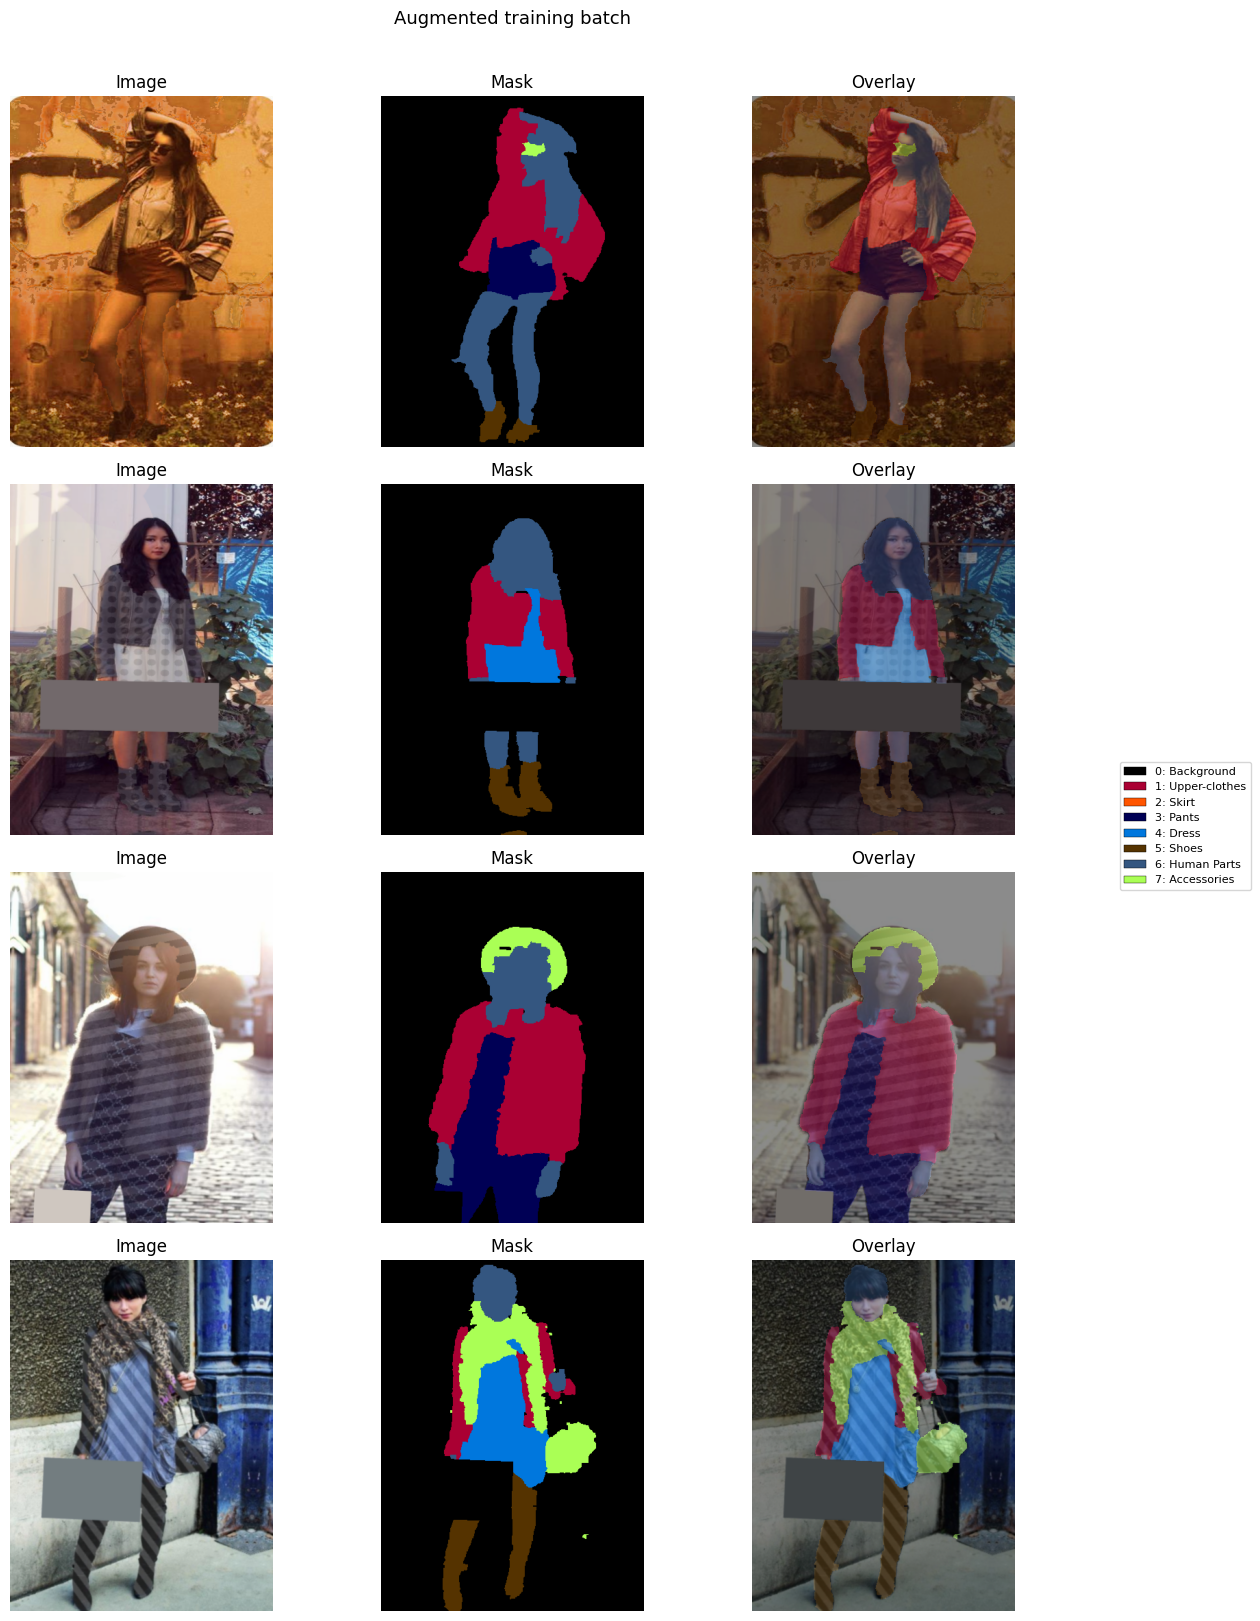

In [10]:
def colorize(mask, palette):
    return palette[mask.astype(np.int64)]

def denormalize(tensor):
    mean = np.array(IMAGENET_MEAN).reshape(3,1,1)
    std  = np.array(IMAGENET_STD ).reshape(3,1,1)
    img  = tensor.numpy() * std + mean
    return (np.clip(img,0,1)*255).astype(np.uint8).transpose(1,2,0)

def plot_batch(batch, n, palette, id2label):
    images = batch['image'][:n]
    masks  = batch['mask'] [:n]
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    if n == 1: axes = axes[None]
    for i in range(n):
        img  = denormalize(images[i])
        msk  = masks[i].numpy()
        cmsk = colorize(msk, palette)
        ov   = (0.55*img + 0.45*cmsk).astype(np.uint8)
        axes[i,0].imshow(img);  axes[i,0].set_title('Image');   axes[i,0].axis('off')
        axes[i,1].imshow(cmsk); axes[i,1].set_title('Mask');    axes[i,1].axis('off')
        axes[i,2].imshow(ov);   axes[i,2].set_title('Overlay'); axes[i,2].axis('off')
    handles = [mpatches.Patch(facecolor=palette[i]/255, edgecolor='black',
                              linewidth=0.3, label=f'{i}: {lbl}')
               for i, lbl in id2label.items()]
    fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.12,0.5), fontsize=8)
    plt.suptitle('Augmented training batch', fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

batch = next(iter(train_loader))
plot_batch(batch, n=4, palette=MERGED_PALETTE, id2label=MERGED_ID2LABEL)

# Model Development
## DeepLabV3+ with MobileNetV2 backbone
- MobileNetV2 backbone — similar parameter count to SegFormer-B0 (~3.4M encoder), keeps comparison fair
- ImageNet pretrained encoder — same level of pretraining as SegFormer
- Output is already [B, NUM_CLASSES, H, W] at full resolution — no wrapper needed unlike SegFormer

In [11]:
_deepLabV3 = smp.DeepLabV3Plus(
    encoder_name    = 'resnet50',   
    encoder_weights = 'imagenet',       
    in_channels     = 3,
    classes         = NUM_CLASSES,      # 8
).to(DEVICE)

total_params = sum(p.numel() for p in _deepLabV3.parameters()) / 1e6
print(f'Model: DeepLabV3+ (resnet50) | {total_params:.1f}M parameters')

# Quick shape check
dummy = torch.randn(2, 3, IMAGE_H, IMAGE_W).to(DEVICE)
with torch.no_grad():
    out = _deepLabV3(dummy)
print(f'Output shape: {out.shape}')  # should be [2, 8, 512, 384]

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Model: DeepLabV3+ (resnet50) | 26.7M parameters
Output shape: torch.Size([2, 8, 512, 384])


## Class Weights

In [12]:
WEIGHTS_PATH = '/kaggle/input/datasets/habibafathalla25/atr-merged-preprocessed/wholeData_class_weights.pt'

if os.path.exists(WEIGHTS_PATH):
    print('Loading saved class weights...')
    class_weights = torch.load(WEIGHTS_PATH, map_location=DEVICE)
else:
    print('Computing class weights...')
    class_pixel_counts = torch.zeros(NUM_CLASSES)
    for batch in tqdm(train_loader, desc='Counting pixels per class'):
        masks = batch['mask']
        for class_id in range(NUM_CLASSES):
            class_pixel_counts[class_id] += (masks == class_id).sum()
    class_freq    = class_pixel_counts / class_pixel_counts.sum()
    class_weights = 1.0 / torch.sqrt(class_freq + 1e-6)
    class_weights = class_weights / class_weights.sum()
    torch.save(class_weights.cpu(), WEIGHTS_PATH)

class_weights = class_weights.to(DEVICE)
print('Class weights:')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:<15}: {class_weights[i].item():.4f}')

Loading saved class weights...
Class weights:
  Background     : 0.0236
  Upper-clothes  : 0.0840
  Skirt          : 0.1683
  Pants          : 0.1242
  Dress          : 0.1351
  Shoes          : 0.2143
  Human Parts    : 0.0815
  Accessories    : 0.1689


## Loss, Metrics, Optimizer

In [13]:
ce_loss   = nn.CrossEntropyLoss(weight=class_weights)
dice_loss = smp.losses.DiceLoss(mode='multiclass', from_logits=True)

def compute_loss(predictions, targets):
    return ce_loss(predictions, targets) + DICE_WEIGHT * dice_loss(predictions, targets)

In [14]:
def compute_miou(predictions, targets):
    pred_classes  = predictions.argmax(dim=1)   # [B, H, W]
    iou_per_class = []

    for class_id in range(NUM_CLASSES):
        predicted_as_class = (pred_classes == class_id)
        actually_class     = (targets      == class_id)
        intersection = (predicted_as_class & actually_class).sum().float()
        union        = (predicted_as_class | actually_class).sum().float()
        if union > 0:
            iou_per_class.append((intersection / union).item())
        else:
            iou_per_class.append(float('nan'))   # class not present in this batch

    present  = [v for v in iou_per_class if not np.isnan(v)]
    mean_iou = sum(present) / len(present) if present else 0.0
    return mean_iou, iou_per_class

In [15]:
optimizer    = AdamW(_deepLabV3.parameters(), lr=LR, weight_decay=1e-4)
total_steps  = NUM_EPOCHS * len(train_loader)

def poly_lr_schedule(current_step):
    progress = current_step / total_steps
    return max(0.0, (1.0 - progress) ** 0.9)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=poly_lr_schedule)
scaler    = GradScaler(DEVICE.type)

print(f'Total training steps: {total_steps:,}')

Total training steps: 52,200


# Training Loop

In [ ]:

BEST_CKPT = "/kaggle/working/best_model.pth"
RESUME_PATH = "/kaggle/input/datasets/moniemfathalla/best-model/best_model.pth"
# ── TRACKING ──────────────────────────────────────────────────────────────────
train_losses, val_losses = [], []
train_mious,  val_mious  = [], []
best_miou         = 0.0
START_EPOCH       = 1
epochs_no_improve = 0
PATIENCE          = 7


def find_latest_checkpoint(path):
    """
    Accept either:
    1. a direct .pth checkpoint file
    2. a directory containing epoch_*.pth or best_model.pth
    """

    # Case 1: direct file path
    if os.path.isfile(path) and path.endswith(".pth"):
        return path

    # Case 2: directory
    if os.path.isdir(path):
        epoch_files = glob.glob(os.path.join(path, "epoch_*.pth"))

        if epoch_files:
            def get_epoch_num(file_path):
                name = os.path.basename(file_path)
                match = re.search(r"epoch_(\d+)\.pth$", name)
                return int(match.group(1)) if match else -1

            return sorted(epoch_files, key=get_epoch_num)[-1]

        best = os.path.join(path, "best_model.pth")
        if os.path.exists(best):
            return best

    return None


resume_path = find_latest_checkpoint(RESUME_PATH)

if resume_path:
    ckpt = torch.load(resume_path, map_location=DEVICE)

    _deepLabV3.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])

    START_EPOCH       = ckpt["epoch"] + 1
    best_miou         = ckpt["best_miou"]
    train_losses      = ckpt.get("train_losses", [])
    val_losses        = ckpt.get("val_losses", [])
    train_mious       = ckpt.get("train_mious", [])
    val_mious         = ckpt.get("val_mious", [])
    epochs_no_improve = ckpt.get("epochs_no_improve", 0)

    print(f"Resumed from  : {resume_path}")
    print(f"Continuing at : epoch {START_EPOCH}  |  best mIoU so far: {best_miou:.4f}")

else:
    print("No checkpoint found — starting from scratch.")

Resumed from  : /kaggle/input/datasets/moniemfathalla/best-model/best_model.pth
Continuing at : epoch 24  |  best mIoU so far: 0.7965


In [ ]:
for epoch in range(START_EPOCH, NUM_EPOCHS + 1):

    torch.manual_seed(RANDOM_SEED + epoch)

    # ── TRAIN ─────────────────────────────────────────────────────────────────
    _deepLabV3.train()
    epoch_loss = 0.0
    epoch_miou = 0.0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [train]'):
        images = batch['image'].to(DEVICE)
        masks  = batch['mask'].to(DEVICE)

        optimizer.zero_grad()
        with autocast(device_type=DEVICE.type):
            predictions = _deepLabV3(images)
            loss        = compute_loss(predictions, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        miou, _ = compute_miou(predictions.detach(), masks)
        epoch_loss += loss.item()
        epoch_miou += miou

    train_losses.append(epoch_loss / len(train_loader))
    train_mious.append(epoch_miou  / len(train_loader))

    _deepLabV3.eval()
    val_loss  = 0.0
    val_miou  = 0.0
    per_class_iou_sum   = [0.0] * NUM_CLASSES
    per_class_iou_count = [0]   * NUM_CLASSES

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [val]  '):
            images = batch['image'].to(DEVICE)
            masks  = batch['mask'].to(DEVICE)
            with autocast(device_type=DEVICE.type):
                predictions = _deepLabV3(images)
                loss        = compute_loss(predictions, masks)
            miou, class_ious = compute_miou(predictions, masks)
            val_loss += loss.item()
            val_miou += miou
            for class_id, iou in enumerate(class_ious):
                if not np.isnan(iou):
                    per_class_iou_sum[class_id]   += iou
                    per_class_iou_count[class_id] += 1

    val_losses.append(val_loss / len(val_loader))
    val_mious.append(val_miou  / len(val_loader))

    print(f'\nEpoch {epoch:02d} | '
          f'Train Loss: {train_losses[-1]:.4f}  Val Loss: {val_losses[-1]:.4f} | '
          f'Train mIoU: {train_mious[-1]:.4f}  Val mIoU: {val_mious[-1]:.4f}')

    if epoch % 5 == 0:
        print('  Per-class IoU:')
        for c in range(NUM_CLASSES):
            avg = per_class_iou_sum[c]/per_class_iou_count[c] if per_class_iou_count[c]>0 else 0.0
            print(f'    {CLASS_NAMES[c]:<15}: {avg:.4f}')


    ckpt_dict = {
        "epoch"               : epoch,
        "model_state_dict"    : _deepLabV3.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_miou"           : best_miou,
        "train_losses"        : train_losses,
        "val_losses"          : val_losses,
        "train_mious"         : train_mious,
        "val_mious"           : val_mious,
        "epochs_no_improve"   : epochs_no_improve,
    }

    # ── BEST MODEL SAVE ───────────────────────────────────────────────────────
    if val_mious[-1] > best_miou:
        best_miou             = val_mious[-1]
        ckpt_dict["best_miou"] = best_miou   # update before saving
        epochs_no_improve     = 0
        torch.save(ckpt_dict, BEST_CKPT)
        print(f"Best model saved  (val mIoU = {best_miou:.4f})")
    else:
        epochs_no_improve += 1
        print(f"No improvement: {epochs_no_improve}/{PATIENCE} epochs")
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping after epoch {epoch}.")
            break

    if epoch % 3 == 0:
        periodic_path = f"/kaggle/working/epoch_{epoch:02d}.pth"
        ckpt_dict["epochs_no_improve"] = epochs_no_improve  # keep in sync
        torch.save(ckpt_dict, periodic_path)
        print(f"  Periodic checkpoint → {periodic_path}")


Epoch 24/50 [train]:   0%|          | 0/1044 [00:00<?, ?it/s]

Epoch 24/50 [val]  :   0%|          | 0/63 [00:00<?, ?it/s]


Epoch 24 | Train Loss: 0.2322  Val Loss: 0.2889 | Train mIoU: 0.8072  Val mIoU: 0.7885
No improvement: 7/7 epochs
Early stopping after epoch 24.


# Training Curves

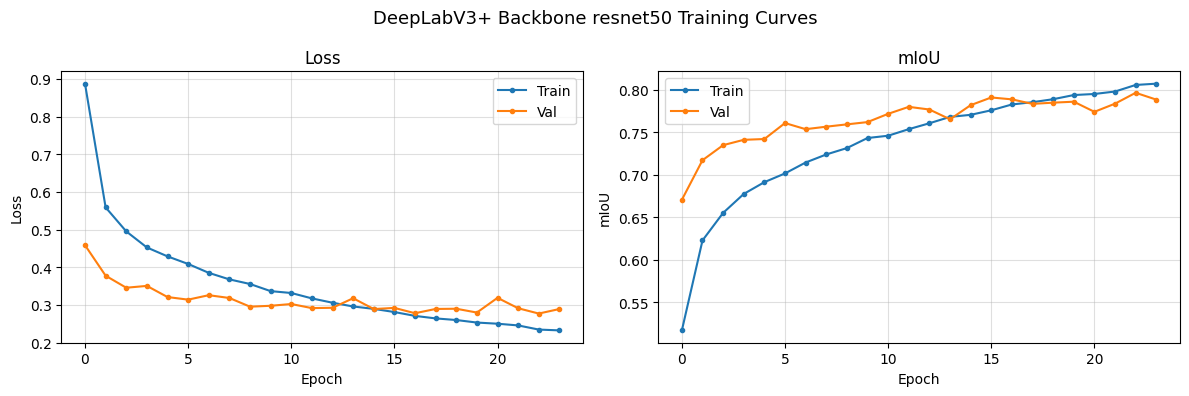

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train', marker='o', markersize=3)
ax1.plot(val_losses,   label='Val',   marker='o', markersize=3)
ax1.set_title('Loss');  ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.4)

ax2.plot(train_mious, label='Train', marker='o', markersize=3)
ax2.plot(val_mious,   label='Val',   marker='o', markersize=3)
ax2.set_title('mIoU'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('mIoU')
ax2.legend(); ax2.grid(True, alpha=0.4)

plt.suptitle('DeepLabV3+ Backbone resnet50 Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves_deeplab_backbone_resnet50.png', dpi=150)
plt.show()

## Confusion Matrix Helpers

In [19]:
def update_confusion_matrix(conf_matrix, predictions, targets):
    pred_classes = predictions.argmax(dim=1)
    pred_flat    = pred_classes.view(-1).cpu()
    target_flat  = targets.view(-1).cpu()
    valid_mask   = target_flat < NUM_CLASSES
    pred_flat    = pred_flat[valid_mask]
    target_flat  = target_flat[valid_mask]
    cell_indices = NUM_CLASSES * target_flat + pred_flat
    conf_matrix += torch.bincount(cell_indices, minlength=NUM_CLASSES*NUM_CLASSES) \
                        .reshape(NUM_CLASSES, NUM_CLASSES)
    return conf_matrix


def get_metrics_from_confusion_matrix(conf_matrix):
    cm = conf_matrix.float()
    tp = cm.diag()
    fp = cm.sum(dim=0) - tp
    fn = cm.sum(dim=1) - tp
    iou       = tp / (tp + fp + fn + 1e-6)
    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)
    return {
        'pixel_accuracy': (tp.sum() / cm.sum()).item(),
        'mean_accuracy' : (tp / (cm.sum(dim=1) + 1e-6)).mean().item(),
        'miou'          : iou.mean().item(),
        'iou_per_class' : iou.tolist(),
        'precision'     : precision.tolist(),
        'recall'        : recall.tolist(),
        'f1'            : f1.tolist(),
    }


def plot_confusion_matrix(conf_matrix, class_names, normalize=True):
    cm = conf_matrix.float().numpy()
    if normalize:
        cm  = cm / (cm.sum(axis=1, keepdims=True) + 1e-6)
        fmt = '.2f'
    else:
        fmt = '.0f'
    fig, ax = plt.subplots(figsize=(11, 9))
    img = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1 if normalize else cm.max())
    plt.colorbar(img, ax=ax)
    ticks = np.arange(len(class_names))
    ax.set_xticks(ticks); ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(ticks); ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel('Predicted label', fontsize=10)
    ax.set_ylabel('True label',      fontsize=10)
    ax.set_title('DeepLabV3+ "resnet50" Confusion Matrix (row-normalised)' if normalize
                 else 'DeepLabV3+ "resnet50" Confusion Matrix (counts)', fontsize=12)
    threshold = cm.max() / 2.0
    for row, col in itertools.product(range(len(class_names)), range(len(class_names))):
        ax.text(col, row, format(cm[row,col], fmt), ha='center', va='center',
                fontsize=6, color='white' if cm[row,col] > threshold else 'black')
    plt.tight_layout()
    plt.savefig('Confusion matrix deeplab backbone resnet50.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Confusion matrix deeplab Backbone resnet50.png')

In [20]:
def get_classes_in_mask(mask, id2label, ignore_background=True):

    class_ids = sorted(np.unique(mask).tolist())

    names = []

    for class_id in class_ids:
        class_id = int(class_id)

        if ignore_background and class_id == 0:
            continue

        if class_id in id2label:
            names.append(id2label[class_id])

    return names

In [21]:
def predict_batch(model, images, masks):

    predictions = model(images)

    pred_masks = predictions.argmax(dim=1)

    return predictions, pred_masks

# Test Evaluation

In [ ]:
def show_test_predictions_with_metrics(
    model,
    test_loader,
    palette,
    id2label,
    num_images=5,
    overlay_alpha=0.45,
    include_background=False
):

    model.eval()
    shown = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Showing test predictions"):

            images_cpu = batch["image"]
            masks_cpu  = batch["mask"]

            images = images_cpu.to(DEVICE)
            masks  = masks_cpu.to(DEVICE).long()

            predictions, pred_masks = predict_batch(
                model=model,
                images=images,
                masks=masks
            )

            batch_size = images.shape[0]

            for i in range(batch_size):

                img = denormalize(images_cpu[i].cpu())

                true_mask = masks_cpu[i].cpu().numpy()
                pred_mask = pred_masks[i].cpu().numpy()

                true_color = colorize(true_mask, palette)
                pred_color = colorize(pred_mask, palette)

                overlay = (
                    (1 - overlay_alpha) * img +
                    overlay_alpha * pred_color
                ).astype(np.uint8)

                single_conf_matrix = torch.zeros(
                    NUM_CLASSES,
                    NUM_CLASSES,
                    dtype=torch.long
                )

                single_prediction = predictions[i:i+1].cpu()
                single_target     = masks[i:i+1].cpu()

                single_conf_matrix = update_confusion_matrix(
                    single_conf_matrix,
                    single_prediction,
                    single_target
                )

                metrics = get_metrics_from_confusion_matrix(single_conf_matrix)


                gt_classes = get_classes_in_mask(
                    true_mask,
                    id2label=id2label,
                    ignore_background=True
                )

                pred_classes = get_classes_in_mask(
                    pred_mask,
                    id2label=id2label,
                    ignore_background=True
                )

                fig, axes = plt.subplots(1, 4, figsize=(16, 5))

                axes[0].imshow(img)
                axes[0].set_title("Image")
                axes[0].axis("off")

                axes[1].imshow(true_color)
                axes[1].set_title("Ground Truth")
                axes[1].axis("off")

                axes[2].imshow(pred_color)
                axes[2].set_title("Generated Mask")
                axes[2].axis("off")

                axes[3].imshow(overlay)
                axes[3].set_title("Overlay")
                axes[3].axis("off")

                plt.tight_layout()
                plt.show()

                print(f"Pixel Accuracy      : {metrics['pixel_accuracy']:.6f}")
                print(f"Mean Class Accuracy : {metrics['mean_accuracy']:.6f}")
                print(f"Mean IoU            : {metrics['miou']:.6f}")
                print("Ground Truth Mask Classes :", ", ".join(gt_classes))
                print("Generated Mask Classes    :", ", ".join(pred_classes))
                print("-" * 90)

                shown += 1

                if shown >= num_images:
                    return

Best DeepLabV3+ Backbone resnet50 model loaded.


Testing:   0%|          | 0/13 [00:00<?, ?it/s]


  Pixel Accuracy      : 96.48%
  Mean Class Accuracy : 81.68%
  Mean IoU (mIoU)     : 69.76%

Class                IoU  Precision   Recall       F1
-------------------------------------------------------
  Background      97.53%     99.94%   97.59%   98.75%
  Upper-clothes   89.39%     93.26%   95.56%   94.40%
  Skirt           56.98%     69.52%   75.95%   72.59%
  Pants           87.08%     93.25%   92.94%   93.09%
  Dress           15.02%     18.86%   42.45%   26.11%
  Shoes           81.76%     83.09%   98.08%   89.97%
  Human Parts     93.49%     94.70%   98.66%   96.64%
  Accessories     36.80%     55.44%   52.25%   53.80%


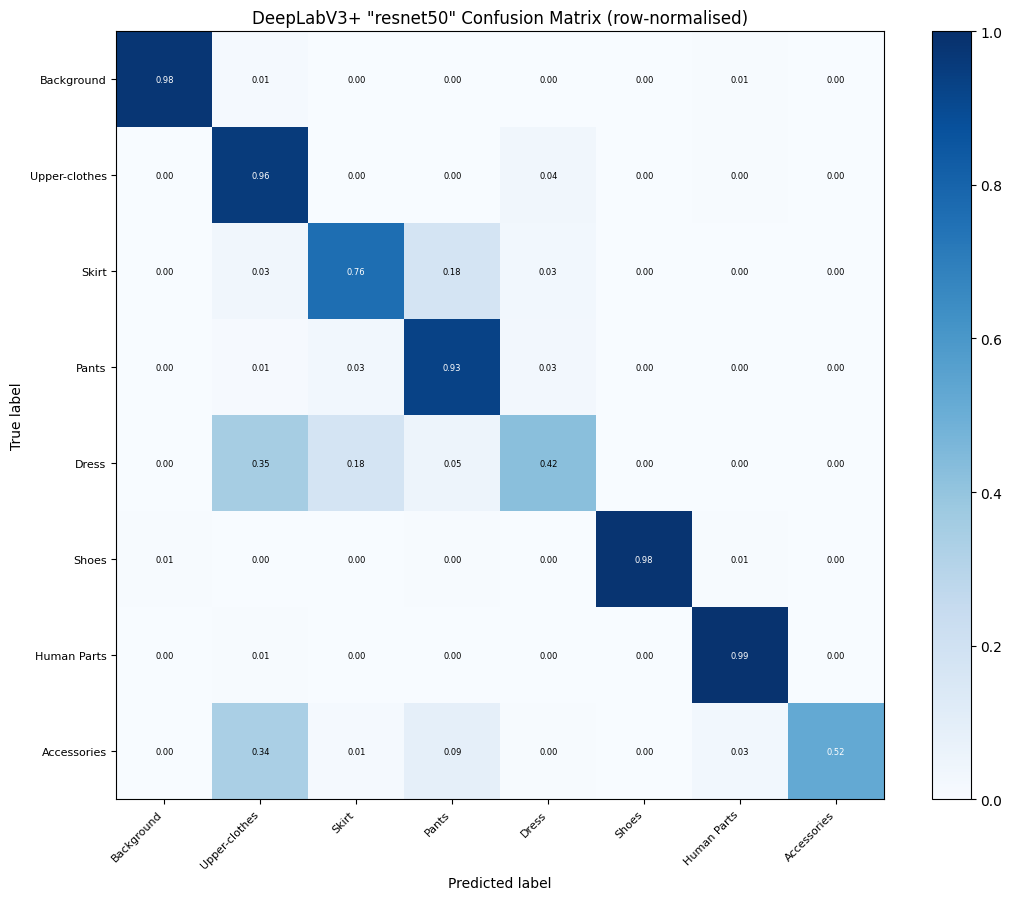

Confusion matrix deeplab Backbone resnet50.png


In [23]:
_deepLabV3.load_state_dict(ckpt_dict["model_state_dict"])
_deepLabV3.eval()
print('Best DeepLabV3+ Backbone resnet50 model loaded.')

conf_matrix = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Testing'):
        images = batch['image'].to(DEVICE)
        masks  = batch['mask'].to(DEVICE)
        with autocast(device_type=DEVICE.type):
            predictions = _deepLabV3(images)
        conf_matrix = update_confusion_matrix(conf_matrix, predictions, masks)

metrics = get_metrics_from_confusion_matrix(conf_matrix)

print(f"\n{'='*55}")
print(f"  Pixel Accuracy      : {metrics['pixel_accuracy'] * 100:.2f}%")
print(f"  Mean Class Accuracy : {metrics['mean_accuracy']  * 100:.2f}%")
print(f"  Mean IoU (mIoU)     : {metrics['miou']           * 100:.2f}%")
print(f"{'='*55}")

print(f"\n{'Class':<16} {'IoU':>7} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print('-' * 55)
for c in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[c]:<14} "
          f"{metrics['iou_per_class'][c]*100:>6.2f}%  "
          f"{metrics['precision'][c]*100:>8.2f}%  "
          f"{metrics['recall'][c]*100:>6.2f}%  "
          f"{metrics['f1'][c]*100:>6.2f}%")

plot_confusion_matrix(conf_matrix, CLASS_NAMES, normalize=True)

Showing test predictions:   0%|          | 0/13 [00:00<?, ?it/s]

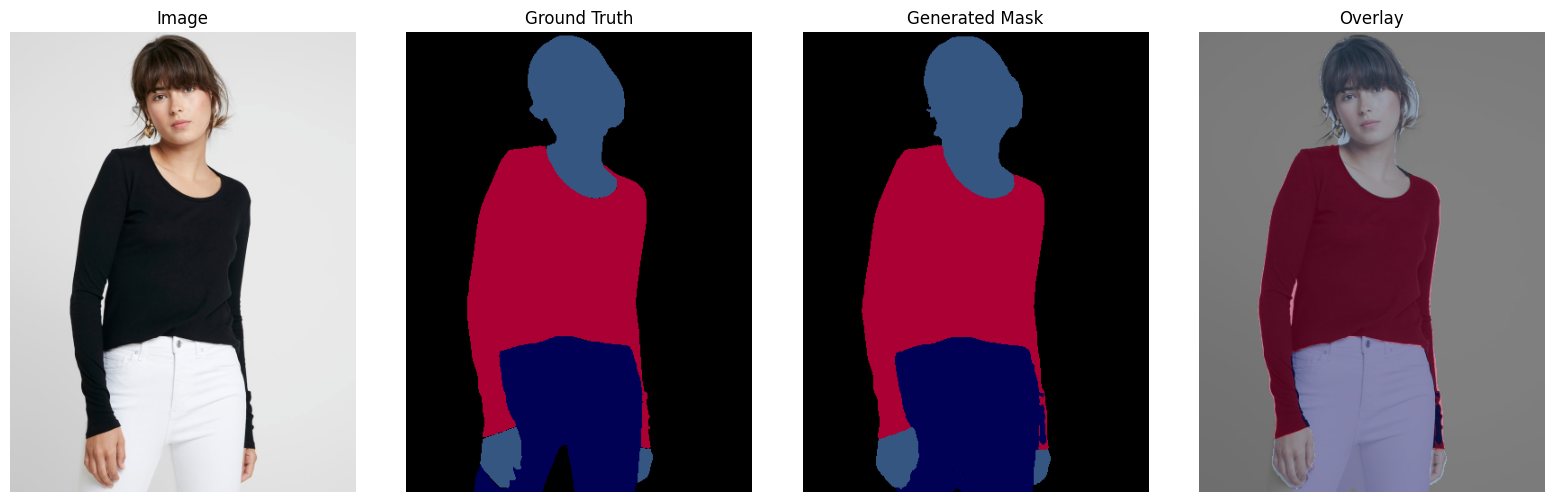

Pixel Accuracy      : 0.978958
Mean Class Accuracy : 0.490584
Mean IoU            : 0.471890
Ground Truth Mask Classes : Upper-clothes, Pants, Human Parts
Generated Mask Classes    : Upper-clothes, Pants, Human Parts
------------------------------------------------------------------------------------------


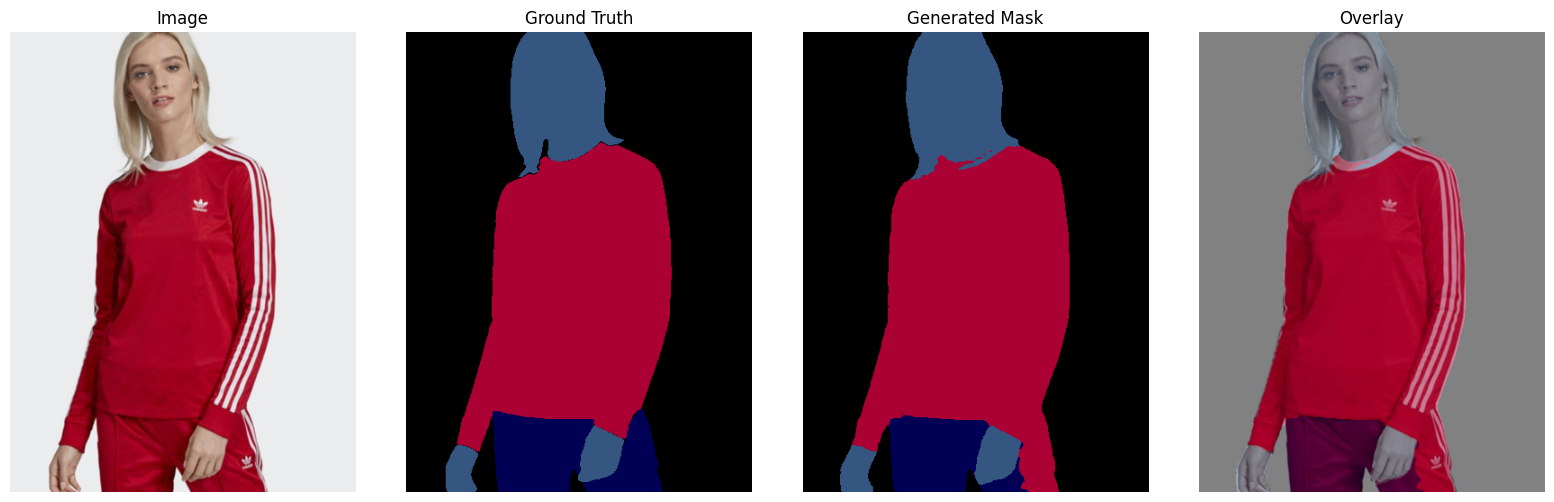

Pixel Accuracy      : 0.971593
Mean Class Accuracy : 0.462399
Mean IoU            : 0.445054
Ground Truth Mask Classes : Upper-clothes, Pants, Human Parts
Generated Mask Classes    : Upper-clothes, Pants, Human Parts
------------------------------------------------------------------------------------------


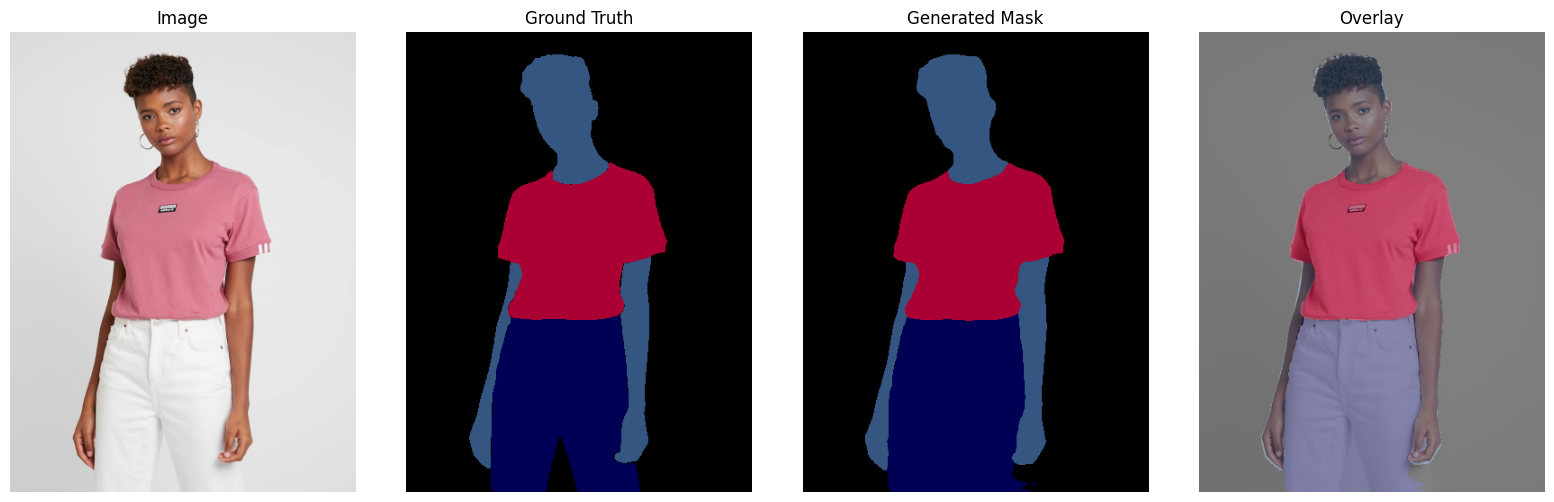

Pixel Accuracy      : 0.983856
Mean Class Accuracy : 0.492935
Mean IoU            : 0.478904
Ground Truth Mask Classes : Upper-clothes, Pants, Human Parts
Generated Mask Classes    : Upper-clothes, Pants, Human Parts
------------------------------------------------------------------------------------------


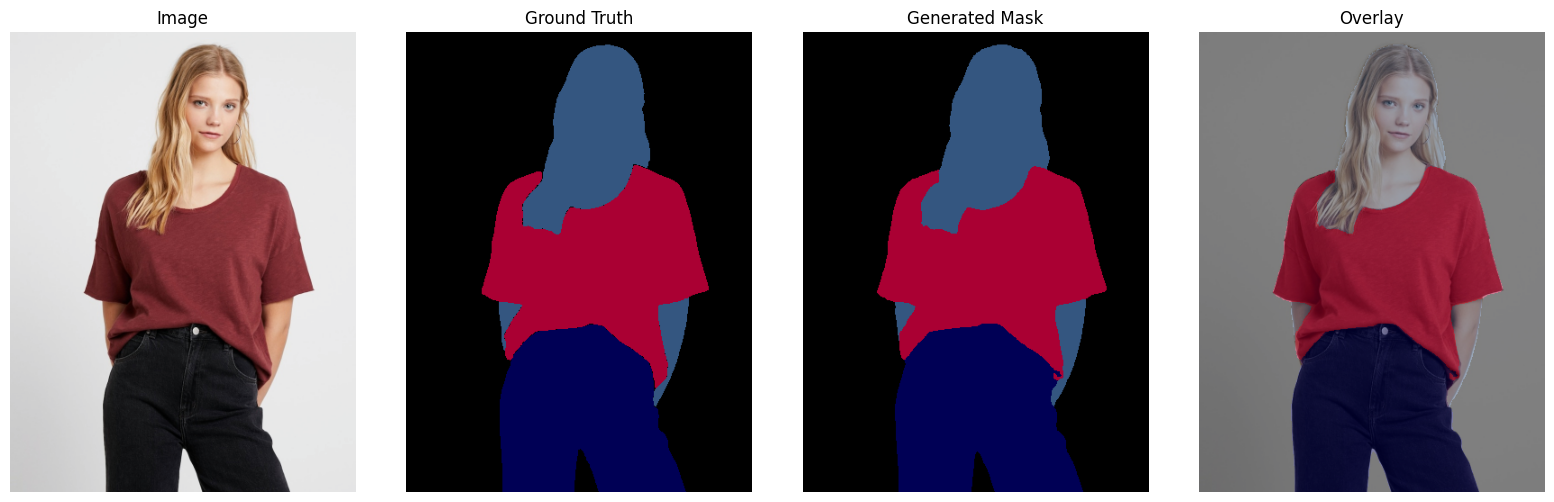

Pixel Accuracy      : 0.990051
Mean Class Accuracy : 0.495197
Mean IoU            : 0.486554
Ground Truth Mask Classes : Upper-clothes, Pants, Human Parts
Generated Mask Classes    : Upper-clothes, Pants, Human Parts
------------------------------------------------------------------------------------------


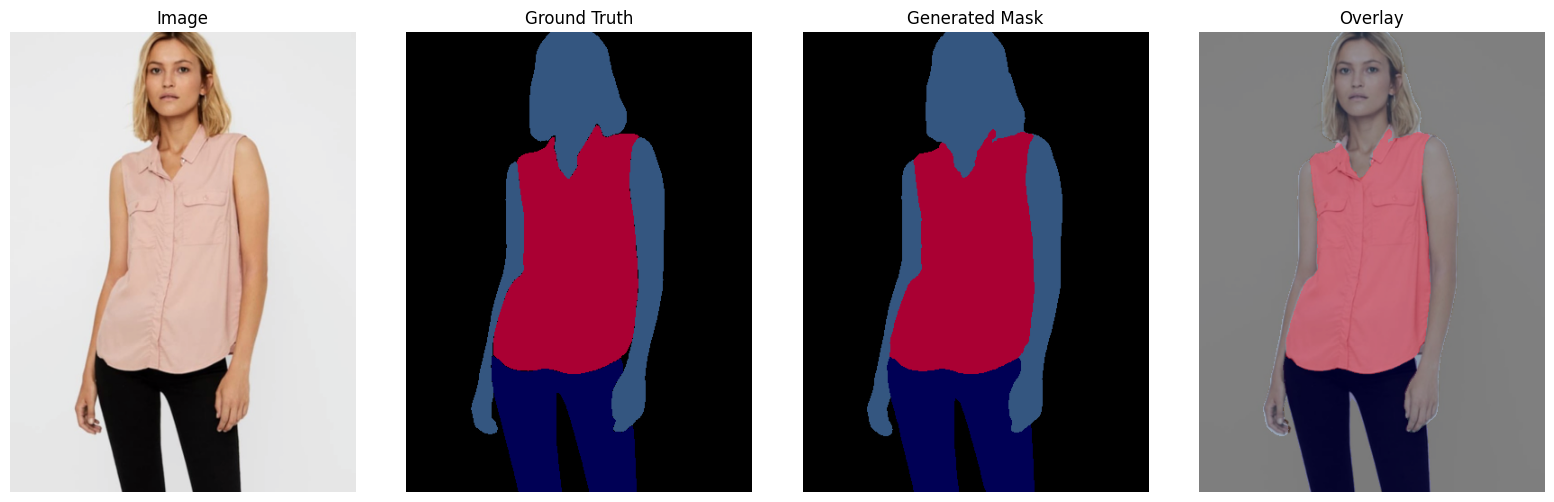

Pixel Accuracy      : 0.988490
Mean Class Accuracy : 0.495500
Mean IoU            : 0.483874
Ground Truth Mask Classes : Upper-clothes, Pants, Human Parts
Generated Mask Classes    : Upper-clothes, Pants, Human Parts
------------------------------------------------------------------------------------------


In [24]:
show_test_predictions_with_metrics(
    model=_deepLabV3,
    test_loader=test_loader,
    palette=MERGED_PALETTE,
    id2label=MERGED_ID2LABEL,
    num_images=5,
    overlay_alpha=0.45,
    include_background=True
)